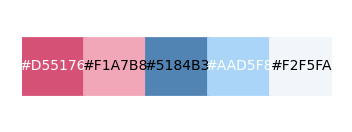

In [1]:
import matplotlib.pyplot as plt

colors = ['#D55176', '#F1A7B8', '#5184B3', '#AAD5F8', '#F2F5FA']
labels = ['#D55176', '#F1A7B8', '#5184B3', '#AAD5F8', '#F2F5FA']

fig, ax = plt.subplots(figsize=(2, 0.6), dpi=200)

for i, (c, lab) in enumerate(zip(colors, labels)):
    # 画色块
    ax.add_patch(plt.Rectangle((i, 0.2), 1, 0.6, color=c))
    
    # 写标签（在色块中间）
    ax.text(i + 0.5, 0.5, lab,
            ha='center', va='center',
            fontsize=5,
            color='white' if i in [0, 3] else 'black')  # 深色用白字更清晰

ax.set_xlim(0, len(colors))
ax.set_ylim(0, 1)
ax.axis('off')

plt.show()

In [2]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

/home/wuke/anaconda3/envs/AIGEM/lib/python3.7/site-packages/Bio/pairwise2.py:283: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  BiopythonDeprecationWarning,


# input and output

# 生成数据

### 1.生成标准enzyme_counts_dict

In [3]:
AGORA2_strainlist_file = '../../Data/AGORA2_strainlist.xlsx'

In [4]:
AGORA2_strainlist = pd.read_excel(AGORA2_strainlist_file,sheet_name='Table_S1')
# AGORA2_strainlist = AGORA2_strainlist[
#     (AGORA2_strainlist['Strain/species reference'].str.contains('human gut')) |
#     (AGORA2_strainlist['MicrobeID'].str.contains('|'.join(case_strain_list)))
# ]
AGORA2_strainlist = AGORA2_strainlist[AGORA2_strainlist['NCBI Taxonomy ID']!=1351]
AGORA2_strainlist[AGORA2_strainlist['NCBI Taxonomy ID']!=562]
AGORA2_strainlist['Genome_type'] = AGORA2_strainlist['Genome link'].apply(lambda x:x.split('//')[0])
AGORA2_strainlist = AGORA2_strainlist[AGORA2_strainlist['Genome_type']=='ftp:']  
AGORA2_strainlist

,MicrobeID,PubSeedID,2 - complete comparative genomics; 1 - certain comparative genomics; 0 - no comparative genomics,Strain,Species,Genus,Family,Order,Class,Phylum,...,Sample Body Site,Sample Body Subsite,Genome Size * assembled,Gene Count * assembled,GC Count * assembled,GC * assembled,CDS Count * assembled,CDS % * assembled,Genome link,Genome_type
0,Abiotrophia_defectiva_ATCC_49176,Abiotrophia defectiva ATCC 49176 (592010.4),2,Abiotrophia defectiva ATCC 49176,Abiotrophia defectiva,Abiotrophia,Aerococcaceae,Lactobacillales,Bacilli,Firmicutes,...,NaN,0.0,2041839.0,2009.0,959280.0,47.0,1950.0,97.06,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:
1,Acaricomes_phytoseiuli_DSM_14247,Acaricomes phytoseiuli DSM 14247 (1120917.3),1,Acaricomes phytoseiuli DSM 14247,Acaricomes phytoseiuli,Acaricomes,Micrococcaceae,Micrococcales,Actinomycetia,Actinobacteria,...,0.0,0.0,2419519.0,2387.0,1506904.0,62.0,2326.0,97.44,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:
2,Acaryochloris_marina_MBIC11017,NaN,0,Acaryochloris marina MBIC11017,Acaryochloris marina,Acaryochloris,Acaryochloridaceae,Synechococcales,unclassified Cyanobacteria,Cyanobacteria,...,0.0,0.0,8361599.0,8488.0,3926263.0,47.0,8409.0,99.07,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:
3,Acetanaerobacterium_elongatum_CGMCC_1_5012,NaN,0,Acetanaerobacterium elongatum,Acetanaerobacterium elongatum,Acetanaerobacterium,Oscillospiraceae,Eubacteriales,Clostridia,Firmicutes,...,0.0,0.0,2916215.0,2842.0,1429234.0,49.0,2773.0,97.57,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/900...,ftp:
4,Acetatifactor_muris_GP69,NaN,0,Acetatifactor muris,Acetatifactor muris,Acetatifactor,Lachnospiraceae,Eubacteriales,Clostridia,Firmicutes,...,0.0,0.0,6013646.0,6002.0,2868509.0,48.0,5901.0,98.32,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/900...,ftp:
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7297,Yersinia_pseudotuberculosis_IP_32953,Yersinia pseudotuberculosis IP 32953 (273123.10),2,Yersinia pseudotuberculosis IP 32953,Yersinia pseudotuberculosis,Yersinia,Yersiniaceae,Enterobacterales,Gammaproteobacteria,Proteobacteria,...,0.0,0.0,4839430.0,4363.0,2301240.0,48.0,4184.0,95.90,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:
7298,Yersinia_pseudotuberculosis_PB1,Yersinia pseudotuberculosis PB1/+ (502801.6),2,Yersinia pseudotuberculosis PB1/+,Yersinia pseudotuberculosis,Yersinia,Yersiniaceae,Enterobacterales,Gammaproteobacteria,Proteobacteria,...,0.0,0.0,4765387.0,4278.0,2262945.0,47.0,4105.0,95.96,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:
7299,Yersinia_pseudotuberculosis_YPIII,Yersinia pseudotuberculosis YPIII (502800.6),2,Yersinia pseudotuberculosis YPIII,Yersinia pseudotuberculosis,Yersinia,Yersiniaceae,Enterobacterales,Gammaproteobacteria,Proteobacteria,...,0.0,0.0,4689441.0,4298.0,2228909.0,48.0,4192.0,97.53,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:
7300,Yersinia_rohdei_ATCC_43380,Yersinia rohdei ATCC 43380 (527004.3),2,Yersinia rohdei ATCC 43380,Yersinia rohdei,Yersinia,Yersiniaceae,Enterobacterales,Gammaproteobacteria,Proteobacteria,...,NaN,0.0,4317478.0,3912.0,2027960.0,47.0,3853.0,98.49,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:


In [5]:
strain_eccounts = {}

clean_result_folder = '/home/wuke/project/bio_deeplearning/Z-Benchmark-EC_predict/CLEAN-0205/app/results/'

for index, row in tqdm(AGORA2_strainlist.iterrows(), total=len(AGORA2_strainlist)):
    ncbiID = row['Genome link'].split('/')[-1]  # 提取 NCBI ID
    strain_family = row['Family']
    clean_result_file = os.path.join(clean_result_folder, f"{ncbiID}_clean_result.json")

    if not os.path.exists(clean_result_file):
        continue  # 如果文件不存在，跳过

    with open(clean_result_file, 'r', encoding='utf-8') as f:
        clean_result = json.load(f)
    # 预处理 clean_result：保留前三位的 EC 号
    # clean_result = {k: ['.'.join(x.split('.')[0:3]) for x in v] for k, v in clean_result.items()}
    for gene,ec_list in clean_result.items():
        for ec in ec_list:
            if ec not in strain_eccounts:
                strain_eccounts[ec] = {}
            if strain_family not in strain_eccounts[ec]:
                strain_eccounts[ec][strain_family] = 0
            else:
                strain_eccounts[ec][strain_family] +=1

100%|██████████| 6244/6244 [00:21<00:00, 284.83it/s]


In [6]:
family_list = [
 'Bifidobacteriaceae',
 'Bacteroidaceae',
 'Porphyromonadaceae',
 'Rikenellaceae',
 'Enterococcaceae',
 'Streptococcaceae',
 'Turicibacteraceae',
 'Clostridiaceae',
 'Lachnospiraceae',
 'Peptostreptococcaceae',
 'Ruminococcaceae',
 'Veillonellaceae',
 'Erysipelotrichaceae',
 'Alcaligenaceae',
 'Enterobacteriaceae',
 ]

strain_eccounts_filter = {
    ec: {family: family_counts.get(family, 0) for family in family_list}
    for ec, family_counts in strain_eccounts.items()
}

##################################### 筛掉全部为0的键值对
strain_eccounts_filter = {
    ec: family_dict
    for ec, family_dict in strain_eccounts_filter.items()
    if any(v > 0 for v in family_dict.values())
}


In [7]:
# ===== EC号排序函数 =====
def sort_ec(ec):
    # 把类似 '1.1.1.1' 变成 [1,1,1,1] 方便排序
    return [int(i) if i.isdigit() else 0 for i in ec.split('.')]

# ===== 对外层 EC号排序 =====
strain_eccounts_filter = dict(
    sorted(strain_eccounts_filter.items(), key=lambda x: sort_ec(x[0]))
)

In [8]:
print(len(strain_eccounts_filter))

4454


# 按照总数计算max_family

In [9]:
max_family_dict = {}

for ec,enzyme_counts in strain_eccounts_filter.items():
    if 'n' not in ec:
        # print('=====================', ec, '=========================')
        max_family = max(enzyme_counts, key=enzyme_counts.get)

        if max_family not in max_family_dict:
            max_family_dict[max_family] = 1
        else:
            max_family_dict[max_family] += 1

max_family_dict

{'Enterobacteriaceae': 2749,
 'Streptococcaceae': 378,
 'Bacteroidaceae': 315,
 'Enterococcaceae': 395,
 'Lachnospiraceae': 178,
 'Clostridiaceae': 142,
 'Erysipelotrichaceae': 33,
 'Bifidobacteriaceae': 73,
 'Alcaligenaceae': 75,
 'Peptostreptococcaceae': 49,
 'Rikenellaceae': 20,
 'Veillonellaceae': 7,
 'Turicibacteraceae': 3}

In [10]:
sorted_items = sorted(max_family_dict.items(), key=lambda x: x[1], reverse=True)

labels = [k for k, v in sorted_items]
sizes = [v for k, v in sorted_items]

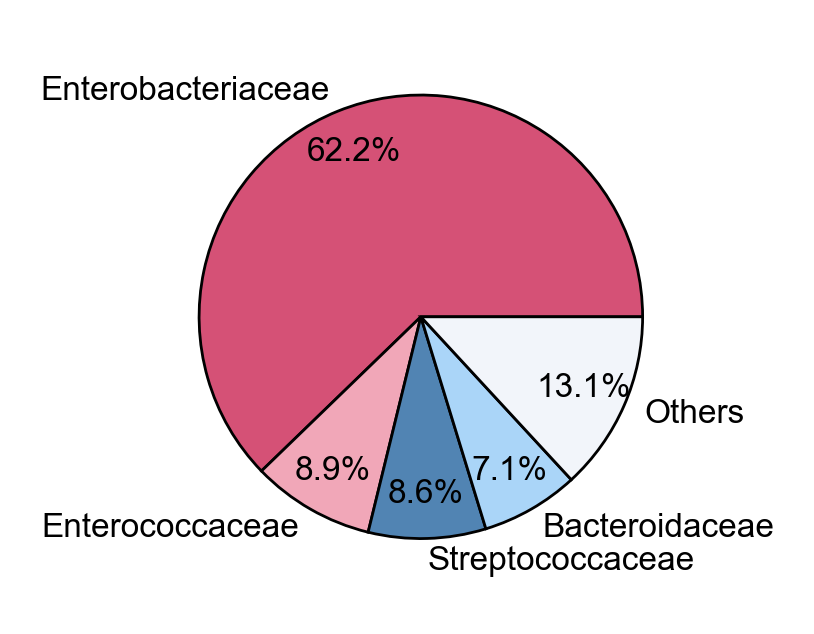

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

# ===== 合并小类（<5%）=====
total = sum(sizes)
new_labels = []
new_sizes = []

other = 0
for l, s in zip(labels, sizes):
    if s / total < 0.05:
        other += s
    else:
        new_labels.append(l)
        new_sizes.append(s)

if other > 0:
    new_labels.append('Others')
    new_sizes.append(other)

# ===== 颜色（修正 + 自动匹配数量）=====
base_colors = ['#D55176', '#F1A7B8', '#5184B3', '#AAD5F8', '#F2F5FA']
colors = list(itertools.islice(itertools.cycle(base_colors), len(new_labels)))

# # Others 设为灰色（更规范）
# if 'Others' in new_labels:
#     idx = new_labels.index('Others')
#     colors[idx] = '#cccccc'

# ===== 画图 =====
plt.figure(figsize=(1.8, 1.8), dpi=400)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

wedges, texts, autotexts = plt.pie(
    new_sizes,
    labels=new_labels,
    colors=colors,
    autopct='%1.1f%%',
    pctdistance=0.80,
    labeldistance=1.1,
    textprops={'fontsize': 6},  # 先统一字体大小
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)

# ===== label 加粗 =====
# for t in texts:
#     t.set_fontweight('bold')

# ===== 百分比保持正常（可显式写一下）=====
for t in autotexts:
    t.set_fontweight('normal')


plt.savefig('../../Figure/Figure-3e.pdf', dpi=400, bbox_inches='tight')

plt.show()

# 按照平均值计算

In [12]:
strain_eccounts_filter

{'1.1.1.n12': {'Bifidobacteriaceae': 0,
  'Bacteroidaceae': 0,
  'Porphyromonadaceae': 0,
  'Rikenellaceae': 0,
  'Enterococcaceae': 1,
  'Streptococcaceae': 0,
  'Turicibacteraceae': 0,
  'Clostridiaceae': 0,
  'Lachnospiraceae': 0,
  'Peptostreptococcaceae': 0,
  'Ruminococcaceae': 0,
  'Veillonellaceae': 0,
  'Erysipelotrichaceae': 0,
  'Alcaligenaceae': 3,
  'Enterobacteriaceae': 3},
 '1.1.1.n11': {'Bifidobacteriaceae': 0,
  'Bacteroidaceae': 0,
  'Porphyromonadaceae': 0,
  'Rikenellaceae': 0,
  'Enterococcaceae': 0,
  'Streptococcaceae': 0,
  'Turicibacteraceae': 0,
  'Clostridiaceae': 0,
  'Lachnospiraceae': 0,
  'Peptostreptococcaceae': 0,
  'Ruminococcaceae': 0,
  'Veillonellaceae': 0,
  'Erysipelotrichaceae': 0,
  'Alcaligenaceae': 0,
  'Enterobacteriaceae': 86},
 '1.1.1.n4': {'Bifidobacteriaceae': 0,
  'Bacteroidaceae': 0,
  'Porphyromonadaceae': 0,
  'Rikenellaceae': 0,
  'Enterococcaceae': 0,
  'Streptococcaceae': 0,
  'Turicibacteraceae': 0,
  'Clostridiaceae': 0,
  'Lachn

In [13]:
family_strain_counts = {'Enterobacteriaceae': 1503,
 'Streptococcaceae': 670,
 'Enterococcaceae': 482,
 'Lachnospiraceae': 120,
 'Bifidobacteriaceae': 110,
 'Bacteroidaceae': 105,
 'Clostridiaceae': 101,
 'Peptostreptococcaceae': 79,
 'Erysipelotrichaceae': 31,
 'Veillonellaceae': 26,
 'Porphyromonadaceae': 13,
 'Rikenellaceae': 13,
 'Alcaligenaceae': 13,
 'Turicibacteraceae': 3,
 'Ruminococcaceae': 2}

In [14]:
strain_eccounts_filter_mean = {}
for ec,strain_eccounts_dict in strain_eccounts_filter.items():
    strain_eccounts_dict = {k:v/family_strain_counts[k] for k,v in strain_eccounts_dict.items()}
    strain_eccounts_filter_mean[ec] = strain_eccounts_dict

In [15]:
max_family_dict = {}

for ec,enzyme_counts in strain_eccounts_filter_mean.items():
    if 'n' not in ec:
        # print('=====================', ec, '=========================')
        max_family = max(enzyme_counts, key=enzyme_counts.get)

        if max_family not in max_family_dict:
            max_family_dict[max_family] = 1
        else:
            max_family_dict[max_family] += 1

max_family_dict

{'Enterobacteriaceae': 1493,
 'Ruminococcaceae': 153,
 'Bacteroidaceae': 420,
 'Alcaligenaceae': 371,
 'Enterococcaceae': 499,
 'Turicibacteraceae': 242,
 'Lachnospiraceae': 169,
 'Peptostreptococcaceae': 92,
 'Rikenellaceae': 308,
 'Clostridiaceae': 177,
 'Streptococcaceae': 194,
 'Erysipelotrichaceae': 189,
 'Bifidobacteriaceae': 75,
 'Veillonellaceae': 19,
 'Porphyromonadaceae': 16}

In [16]:
sorted_items = sorted(max_family_dict.items(), key=lambda x: x[1], reverse=True)

labels = [k for k, v in sorted_items]
sizes = [v for k, v in sorted_items]

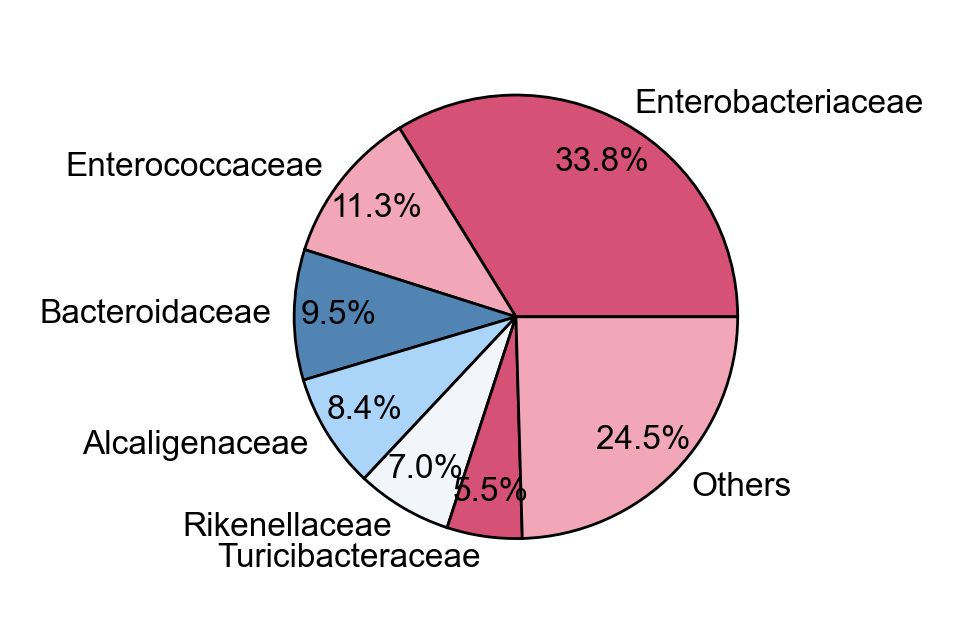

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

# ===== 合并小类（<5%）=====
total = sum(sizes)
new_labels = []
new_sizes = []

other = 0
for l, s in zip(labels, sizes):
    if s / total < 0.05:
        other += s
    else:
        new_labels.append(l)
        new_sizes.append(s)

if other > 0:
    new_labels.append('Others')
    new_sizes.append(other)

# ===== 颜色（修正 + 自动匹配数量）=====
base_colors = ['#D55176', '#F1A7B8', '#5184B3', '#AAD5F8', '#F2F5FA']
colors = list(itertools.islice(itertools.cycle(base_colors), len(new_labels)))

# # Others 设为灰色（更规范）
# if 'Others' in new_labels:
#     idx = new_labels.index('Others')
#     colors[idx] = '#cccccc'

# ===== 画图 =====
plt.figure(figsize=(1.8, 1.8), dpi=400)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

wedges, texts, autotexts = plt.pie(
    new_sizes,
    labels=new_labels,
    colors=colors,
    autopct='%1.1f%%',
    pctdistance=0.80,
    labeldistance=1.1,
    textprops={'fontsize': 6},  # 先统一字体大小
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)

# ===== label 加粗 =====
# for t in texts:
#     t.set_fontweight('bold')

# ===== 百分比保持正常（可显式写一下）=====
for t in autotexts:
    t.set_fontweight('normal')
    
# plt.savefig('../../Figure/Figure-S7.pdf', dpi=400, bbox_inches='tight')
plt.savefig('../../Figure/Figure-S7.tiff',dpi=400,bbox_inches='tight',format='tiff')
plt.show()